# Attempt to reproduce [Ref. 1: Deep-Learning-Based Classification of Digitally Modulated Signals Using Capsule Networks and Cyclic Cumulants](https://www.mdpi.com/1424-8220/23/12/5735)

Try to fully reproduce [Ref. 1](https://www.mdpi.com/1424-8220/23/12/5735). The original paper is based on Matlab, and I plan to convert it to a PyTorch version.

## Part1 CC Feature Extraction and Cyclic Cumulant Estimate

### Part1.1 Configuration, dataset, and tim data reading

In [1]:
import os
import math
from functools import lru_cache
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
# ============================================================
# Config
# ============================================================
USE_GPU = True
TORCH_DEVICE = "cuda:1" if (USE_GPU and torch.cuda.is_available()) else "cpu"
TORCH_COMPLEX = torch.complex128   
TORCH_REAL = torch.float64
print(f"Using device: {TORCH_DEVICE}")
# ============================================================
# Dataset switch
# ============================================================
DATASET_NAME = "2022"   # "2022" or "2018"
ROOT_MAP = {
    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",
    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",
}

if DATASET_NAME not in ROOT_MAP:
    raise ValueError(f"Unsupported DATASET_NAME: {DATASET_NAME}")
ROOT_DATA = ROOT_MAP[DATASET_NAME]

FS_IN = 1.0              # dataset sampling frequency is normalized to 1
N_PER_BATCH = 4000
N_BATCHES = 28
N_TOTAL = N_PER_BATCH * N_BATCHES  # 112000
SAMPLES_PER_SIG = 32768
# User controls
INDEX_START = 1          # 1-based global signal index
N_ROWS = 2               # plot rows
N_COLS = 8               # plot cols
MAX_K = 5                # k = -5..5 => 11 rows
REMOVE_MEAN = False      # paper Section 2.2 does not require mean removal
EPS = 1e-12
def to_torch_complex(x, device=TORCH_DEVICE):
    if isinstance(x, torch.Tensor):
        return x.to(device=device, dtype=TORCH_COMPLEX)
    x = np.asarray(x)
    x = np.ascontiguousarray(x)
    return torch.as_tensor(x, dtype=TORCH_COMPLEX, device=device)
def torch_complex_to_numpy(x):
    """
    torch tensor -> numpy
    """
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return x 

Using device: cuda:1


### Part1.2 Read CFO, symbol rate, and basic pattern from the truth value txt file.

This function reads the dataset truth-label file and converts the raw metadata into the parameter set needed by the later CC computation stage. In particular, it derives:

- `SymbolRate`
- `T0_eff`
- `CFO`

from the dataset columns such as `BaseSymbolPeriod`, `UpsampleFactor`, `DownsampleFactor`, and `CarrierOffset`.

The Ref.1 states that accurate CC estimation requires knowledge of the **symbol rate** and **CFO**, because these parameters determine the cycle frequencies at which the cyclic cumulants should be evaluated. In the Ref.1, these parameters are supposed to be obtained blindly using CSP-based procedures such as SSCA and related processing. In this code, however, they are obtained directly from the truth table so that the downstream CC estimator can be tested independently.


In [2]:
LABEL_MAP = {
    "2022": "CSPB_ML_2022_Signal_Truth_Labels.txt",
    "2018": "CSPB_ML_2018_Signal_Truth_Labels.txt",
}
LABEL_PATH = os.path.join(ROOT_DATA, LABEL_MAP[DATASET_NAME])
# ============================================================
# Truth labels
# ============================================================
def load_truth_labels(label_path: str) -> pd.DataFrame:
    """
    Read the truth-label txt file.

    Expected columns:
      SignalIndex  SignalType  BaseSymbolPeriod  CarrierOffset
      ExcessBandwidth  UpsampleFactor  DownsampleFactor
      InbandSNRdB  NoiseSpectralDensitydB
    """
    df = pd.read_csv(label_path, delim_whitespace=True)
    expected = [
        "SignalIndex", "SignalType", "BaseSymbolPeriod", "CarrierOffset",
        "ExcessBandwidth", "UpsampleFactor", "DownsampleFactor",
        "InbandSNRdB", "NoiseSpectralDensitydB"
    ]
    if list(df.columns) != expected:
        raise ValueError(
            f"Unexpected label columns.\n"
            f"Got     : {list(df.columns)}\n"
            f"Expected: {expected}"
        )

    # Normalize string type
    df["SignalType"] = df["SignalType"].astype(str).str.lower()

    # Handle the known edge case: DownsampleFactor==0 means no resampling => D=1
    D = df["DownsampleFactor"].to_numpy(dtype=np.float64)
    U = df["UpsampleFactor"].to_numpy(dtype=np.float64)
    Tbase = df["BaseSymbolPeriod"].to_numpy(dtype=np.float64)

    D_eff = np.where(D == 0, 1.0, D)
    U_eff = np.where(U == 0, 1.0, U)

    # Symbol rate in normalized units (cycles/sample)
    # Rs = (1 / BaseSymbolPeriod) * (D / U)
    Rs = D_eff / (U_eff * Tbase)
    T0_eff = 1.0 / Rs

    df["SymbolRate"] = Rs
    df["T0_eff"] = T0_eff
    df["CFO"] = df["CarrierOffset"].astype(np.float64)
    return df

TRUTH_DF = load_truth_labels(LABEL_PATH)
TRUTH_DF = TRUTH_DF.set_index("SignalIndex", drop=False)

def signal_type_to_pattern_hint(sig_type: str) -> str:
    """
    Pattern hint derived from modulation label.
    This is metadata only here; computation below uses the full 11x25 fixed grid.

    Paper says:
      - BPSK / ASK / OOK -> BPSK-like
      - symmetric QAM (>2 points) -> QPSK-like
      - other listed patterns: QPSK-like, pi/4-DQPSK-like, 8PSK-like, SQPSK-like

    For MSK, the paper's five-pattern list does not explicitly say "MSK-like".
    We keep it as an explicit hint string instead of forcing a possibly wrong mapping.
    """
    sig_type = sig_type.lower()
    if sig_type == "bpsk":
        return "BPSK-like"
    if sig_type == "qpsk":
        return "QPSK-like"
    if sig_type == "8psk":
        return "8PSK-like"
    if sig_type == "dqpsk":
        return "pi/4-DQPSK-like"
    if sig_type in {"16qam", "64qam", "256qam"}:
        return "QPSK-like"
    if sig_type == "msk":
        return "SQPSK-like"
    return "Unknown"

def get_truth_params(signal_index: int):
    if signal_index not in TRUTH_DF.index:
        raise ValueError(f"Signal index {signal_index} not found in truth labels.")
    row = TRUTH_DF.loc[signal_index]
    return {
        "signal_index": int(row["SignalIndex"]),
        "signal_type": str(row["SignalType"]),
        "pattern_hint": signal_type_to_pattern_hint(str(row["SignalType"])),
        "T0": float(row["T0_eff"]),
        "symbol_rate": float(row["SymbolRate"]),   # cycles/sample
        "f0": float(row["CFO"]),                   # cycles/sample
        "base_symbol_period": float(row["BaseSymbolPeriod"]),
        "upsample": float(row["UpsampleFactor"]),
        "downsample": float(row["DownsampleFactor"]),
        "snr_db": float(row["InbandSNRdB"]),
        "excess_bw": float(row["ExcessBandwidth"]),
    }

/tmp/ipykernel_4143164/1422802469.py:18: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(label_path, delim_whitespace=True)


### Part1.3 File mapping and .tim reader

This function reads one `.tim` file and reconstructs the complex baseband IQ sequence. It interprets the file as:

- two initial `float32` metadata values,
- followed by `32768` interleaved `I,Q` sample pairs,

and returns the resulting complex vector

$$
x[n] = I[n] + jQ[n].
$$

This output is the raw input signal used by the later CTMF and CC estimators. The Ref.1 also assumes a complex digitally modulated signal model of the form

$$
x(t)=a\,s(t)e^{i(2\pi f_0 t+\phi)} + w(t),
$$

so this function is the code-level entry point that provides the discrete-time version of that signal to the estimator.

In [3]:

def global_to_path_and_type(gidx: int):
    """
    1-based global index -> file path
    Uses DATASET_NAME to choose 2018 or 2022.
    """
    if gidx < 1 or gidx > N_TOTAL:
        raise ValueError(f"global index out of range: {gidx} (valid 1..{N_TOTAL})")

    batch_dir = (gidx - 1) // N_PER_BATCH + 1
    tim_path = os.path.join(ROOT_DATA, f"Batch_Dir_{batch_dir}", f"signal_{gidx}.tim")
    return tim_path, batch_dir

def tim_to_complex_iq_32768(tim_path: str) -> np.ndarray:
    """
    Read one .tim file:
      first 2 float32 are metadata,
      then 32768 complex samples stored as interleaved float32 I,Q.
    """
    raw = np.fromfile(tim_path, dtype=np.float32)
    need = 2 + 2 * SAMPLES_PER_SIG
    if raw.size < need:
        raise ValueError(f"{tim_path}: {raw.size} floats < {need}")
    iq = raw[2:need]
    I = iq[0::2].astype(np.float64)
    Q = iq[1::2].astype(np.float64)
    x = I + 1j * Q
    if x.size != SAMPLES_PER_SIG:
        raise ValueError(f"{tim_path}: expected {SAMPLES_PER_SIG} IQ samples, got {x.size}")
    return x

### Part1.4 Blind signal-power estimate for post-warp USP scaling

This function provides a **blind signal-power estimate** used only for the **post-warp scaling** stage. It estimates:

- a rough noise variance from the median FFT power,
- and then computes signal power as total power minus estimated noise power.

This is not the Ref.1’s main CC formula itself. Rather, it is a practical normalization step added so that the warped CC features have a more stable numerical scale across signals. In other words, it supports feature conditioning, not the core cumulant definition.


In [4]:
def estimate_noise_and_signal_power_fft(x, eps=1e-12):
    """
    Blind estimate:
      noise_var ~ median(|FFT|^2) / N
      signal_power = total_power - noise_var

    GPU version using torch. Returns Python floats.
    """
    xt = to_torch_complex(x)
    N = xt.numel()

    X = torch.fft.fft(xt, n=N)
    psd = torch.abs(X) ** 2

    noise_var = torch.median(psd) / max(N, 1)
    total_pow = torch.mean(torch.abs(xt) ** 2)
    sig_pow = torch.clamp(total_pow - noise_var, min=eps)

    return float(noise_var.item()), float(sig_pow.item())

### Part1.5 Set partitions for cumulant-moment relation

These two helper functions generate all distinct **set partitions** of an index set of size `n`. They are required because the cyclic cumulant is constructed from lower-order cyclic temporal moments through the **moment–cumulant relation**.

In the Ref.1, the temporal cumulant function is written as a sum over all distinct partitions of the index set, with coefficient

$$
h(p)=(-1)^{p-1}(p-1)!,
$$

and the same combinatorial structure also appears in the finite-time cyclic cumulant estimate. These helper functions implement exactly that partition bookkeeping in code. Their role is therefore foundational: they allow the code to expand the cumulant into the required signed combination of lower-order moment terms.


In [5]:
@lru_cache(maxsize=None)
def _set_partitions_tuple(n: int):
    """
    All distinct set partitions of {0,1,...,n-1}, returned as tuples of tuples.
    Cached because we repeatedly use n up to 8.
    """
    if n == 0:
        return ((),)
    prev = _set_partitions_tuple(n - 1)
    out = []
    for p in prev:
        # option 1: add new singleton block (n-1)
        p_new = list(list(b) for b in p) + [[n - 1]]
        out.append(p_new)

        # option 2: insert into an existing block
        for i in range(len(p)):
            p2 = [list(b) for b in p]
            p2[i].append(n - 1)
            out.append(p2)
    # canonicalize and deduplicate
    seen = set()
    canon = []
    for p in out:
        blk_sorted = [tuple(sorted(b)) for b in p]
        blk_sorted = tuple(sorted(blk_sorted, key=lambda x: (len(x), x)))
        if blk_sorted not in seen:
            seen.add(blk_sorted)
            canon.append(blk_sorted)
    return tuple(canon)

def _set_partitions(n: int):
    return [[list(block) for block in part] for part in _set_partitions_tuple(n)]

### Part1.6 CTMF estimate (Ref.1 Eq. 10), $\tau = 0$

This is the code’s implementation of the **finite-time cyclic temporal moment function (CTMF)** at **delay vector $\tau=0$**.

For each order pair $(n,m)$, and for cycle-frequency indices $k=-K,\dots,K$, it evaluates

$$
\beta = (n-2m)f_0 + k/T_0,
$$

and then computes the finite-time moment sequence

$$
\hat{R}_x^\beta(\tau;n,m)
=
\frac{1}{T}
\int_0^T
\left[
\prod_{j=1}^{n} x^{(*)_j}(t+\tau_j)
\right]
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\tau=0\;}
\frac{1}{T}
\int_0^T
\left[
\prod_{j=1}^{n} x^{(*)_j}(t)
\right]
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\text{$m$ conjugated terms}\;}
\frac{1}{T}
\int_0^T
x(t)^{\,n-m}\,\overline{x(t)}^{\,m}
e^{-i2\pi\beta t}\,dt
\;\xrightarrow{\;\text{discrete-time}\;}
\frac{1}{N}
\sum_{\ell=0}^{N-1}
x(t_\ell)^{\,n-m}\,\overline{x(t_\ell)}^{\,m}
e^{-i2\pi\beta t_\ell}
$$
This corresponds directly to the Ref.1’s finite-time CTMF estimator, specialized to the case $\tau=0$. The Ref.1 states that the nonzero cycle frequencies are determined by the combination of CFO and symbol rate, and the code follows that formula explicitly by constructing `beta` from `f0`, `T0`, and integer harmonic index `k`.

This function is the first place where the truth-driven simplification becomes operational: since `f0` and `T0` are not blindly estimated here, the function receives them directly from the truth-label path.


In [6]:
def cyclic_moment_sequence_tau0(x, T0, f0, n, m, K, remove_mean=False):
    """
    GPU version:
        R_hat_x^beta(0;n,m) = (1/N) sum_t [ x(t)^(n-m) conj(x(t))^m ] e^{-i2π beta t}

    Returns:
        numpy complex array of shape (2K+1,)
    """
    xt = to_torch_complex(x)

    if remove_mean:
        xt = xt - torch.mean(xt)

    N = xt.numel()
    t = torch.arange(N, dtype=TORCH_REAL, device=xt.device)

    Rs = 1.0 / T0
    ks = torch.arange(-K, K + 1, dtype=TORCH_REAL, device=xt.device)

    beta = (n - 2 * m) * f0 + ks * Rs                  # (2K+1,)
    u = (xt ** (n - m)) * (torch.conj(xt) ** m)       # (N,)

    # E: (2K+1, N)
    E = torch.exp(-1j * 2 * torch.pi * beta[:, None] * t[None, :])

    # Mseq: (2K+1,)
    Mseq = (E @ u) / N

    return torch_complex_to_numpy(Mseq)

### Part1.7 CC estimate (Ref.1 Eq. 11), using partition formula

This function is the core implementation of the **finite-time cyclic cumulant estimator**.

Its logic is:

1. determine which variable slots are conjugated,
2. enumerate all distinct set partitions of order `n`,
3. determine which lower-order CTMFs are needed,
4. compute those CTMFs,
5. combine them using the partition coefficients
   $$
   (-1)^{p-1}(p-1)!,
   $$
6. enforce the cycle-frequency summation rule by convolution over the \(k\)-index.

This is the code realization of the Ref.1’s cyclic cumulant estimate:

$$
\hat{C}_x^\alpha(\tau;n,m)
=
\sum_{P_n}
\left[
h(p)
\sum_{\beta_1^\dagger=\alpha}
\prod_{j=1}^{p}
\hat{R}_{x_{\nu_j}}^{\beta_j}(\tau_{\nu_j};n_j,m_j)
\right].
$$

Thus, this function is the true mathematical center of the reproduction. If `cyclic_moment_sequence_tau0` computes the building blocks, then `cyclic_cumulant_sequence_tau0` assembles those blocks into the final cyclic cumulant sequence.

In [7]:
def _conv_k_sequences(seqs):
    """
    Multi-sequence discrete convolution over the k index.
    Each input sequence is centered at k=0 and has length 2K+1.
    """
    out = np.array([1.0 + 0j], dtype=np.complex128)
    for s in seqs:
        out = np.convolve(out, s, mode="full")
    return out


def cyclic_cumulant_sequence_tau0(x, T0, f0, n, m, K, remove_mean=False):
    """
    Compute C_{n,m}[k], k=-K..K, by:
      - generating all distinct set partitions of order n
      - using h(p) = (-1)^(p-1) (p-1)!
      - summing products of lower-order CTMF estimates
      - enforcing beta_1 + ... + beta_p = alpha via k-index convolution

    This is the finite-time estimator corresponding to paper Eq. (11).
    """
    Nvar = n

    # Mark which variable slots are conjugated:
    # first (n-m) are x, last m are x*
    is_conj = np.zeros(Nvar, dtype=np.int32)
    is_conj[(n - m):] = 1

    partitions = _set_partitions(Nvar)

    # Determine all lower-order (nb, mb) moment types needed
    needed = set()
    for pi in partitions:
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            needed.add((nb, mb))

    # Precompute CTMF sequences for all needed lower-order moment types
    Mcache = {}
    for (nb, mb) in needed:
        Mcache[(nb, mb)] = cyclic_moment_sequence_tau0(
            x=x, T0=T0, f0=f0, n=nb, m=mb, K=K, remove_mean=remove_mean
        )

    # Accumulate on a wide enough k-grid
    full_half = n * K
    center = full_half
    C_full = np.zeros((2 * full_half + 1,), dtype=np.complex128)

    for pi in partitions:
        p = len(pi)
        coef = ((-1) ** (p - 1)) * math.factorial(p - 1)

        seqs = []
        for blk in pi:
            nb = len(blk)
            mb = int(np.sum(is_conj[np.array(blk, dtype=int)]))
            seqs.append(Mcache[(nb, mb)])

        conv = _conv_k_sequences(seqs)
        conv_center = p * K

        lo = center - conv_center
        hi = center + conv_center + 1
        C_full[lo:hi] += coef * conv

    return C_full[center - K:center + K + 1]

def normalize_signal_rms(x, eps=1e-12):
    """
    RMS normalize complex signal:
        x <- x / sqrt(mean(|x|^2))
    """
    x = np.asarray(x, dtype=np.complex128)
    rms = np.sqrt(np.mean(np.abs(x) ** 2))
    return x / (rms + eps)

### Part1.8 11 x 25 paper-style feature map, extended with n=8

This function constructs the final **fixed-grid CC feature map** used downstream.

Its processing is layered as follows:

1. take the raw signal `x`,
2. apply RMS normalization,
3. for each \((n,m)\) pair, call `cyclic_cumulant_sequence_tau0`,
4. take the magnitude of the cumulant sequence,
5. apply the paper-style **warping**
   $$
   |\hat{C}|^{2/n},
   $$
6. optionally apply signal-power scaling,
7. stack the results into a two-dimensional feature matrix.

The produced grid is organized by:

- **rows**: $k=-5,\dots,5$,
- **columns**: different $(n,m)$ combinations.

The paper states that, to reduce computation, it uses:

- $\tau=0$,
- orders $n=\{2,4,6\}$,
- up to $k=5$,

which yields $11$ possible CF positions for each $(n,m)$ pair and a total $11 \times 15 = 165$ CC inputs to the CAP. This code follows the same general construction, but extends the grid with **$n=8$** as an additional experimental branch, so the current implementation produces an **11×24** map before optional masking/cropping. The code also explicitly applies the warping step described in the paper, and performs a blind signal-power scaling after warping. 

The phrase **truth-driven** in the function name is crucial: this feature map is not produced after full blind estimation. It is produced after directly supplying `T0` and `f0` from the truth labels.


In [8]:

def cc_11x24_estimates_truth_driven(
    x,
    T0,
    f0,
    max_k=5,
    remove_mean=False,
    eps=1e-12,
    blind_signal_power_scaling=True
):
    """
    Fixed-grid feature map:
      rows : k = -5..5
      cols : (n,m) for n in {2,4,6,8}, m = 0..n

    Modified version:
      - PRE-normalize signal by RMS before CTMF / CC computation
      - keep post-warp blind signal-power scaling, but estimate it from
        the ORIGINAL signal, not the pre-normalized one
    """
    x_raw = np.asarray(x).astype(np.complex128)

    # --------------------------------------------------------
    # Pre-normalization borrowed from the first code path
    # --------------------------------------------------------
    x_cc = normalize_signal_rms(x_raw, eps=eps)

    K = max_k
    ks = np.arange(-K, K + 1)

    col_pairs = (
        [(2, m) for m in range(3)] +
        [(4, m) for m in range(5)] +
        [(6, m) for m in range(7)] +
        [(8, m) for m in range(9)]
    )

    n_rows = ks.size
    n_cols = len(col_pairs)

    CC_warped_t = torch.zeros((n_rows, n_cols), dtype=TORCH_REAL, device=TORCH_DEVICE)

    for idx, (n, m) in enumerate(col_pairs):
        Cseq = cyclic_cumulant_sequence_tau0(
            x=x_cc,   # use pre-normalized signal for CC computation
            T0=T0,
            f0=f0,
            n=n,
            m=m,
            K=K,
            remove_mean=remove_mean
        )

        Cseq_t = to_torch_complex(Cseq)
        CC_warped_t[:, idx] = torch.pow(torch.abs(Cseq_t) + eps, 2.0 / n)

    sig_pow = 1.0
    if blind_signal_power_scaling:
        # IMPORTANT:
        # estimate signal power from ORIGINAL raw signal
        # so post-warp scaling still reflects the raw signal strength
        _, sig_pow = estimate_noise_and_signal_power_fft(x_raw, eps=eps)
        CC_scaled_t = CC_warped_t / max(sig_pow, eps)
    else:
        CC_scaled_t = CC_warped_t

    CC_scaled = torch_complex_to_numpy(CC_scaled_t).astype(np.float64)

    meta = {
        "k": ks,
        "col_pairs": col_pairs,
        "signal_power_est": sig_pow,
        "shape": CC_scaled.shape,
        "device": TORCH_DEVICE,
        "pre_normalized": True,
    }
    return CC_scaled, meta

### Part1.9 Batch extraction + plot function

The current code does reproduce the following back-end part of the paper reasonably faithfully:

- the use of $\tau=0$,
- the cycle-frequency construction based on
  $
  \alpha = (n-2m)f_0 \pm k/T_0,
  $
- the finite-time CTMF evaluation,
- the cyclic cumulant construction through the partition-based moment–cumulant relation,
- the warped CC feature representation,
- the assembly of a fixed-size feature map for later classification.

Success: 16 / 16


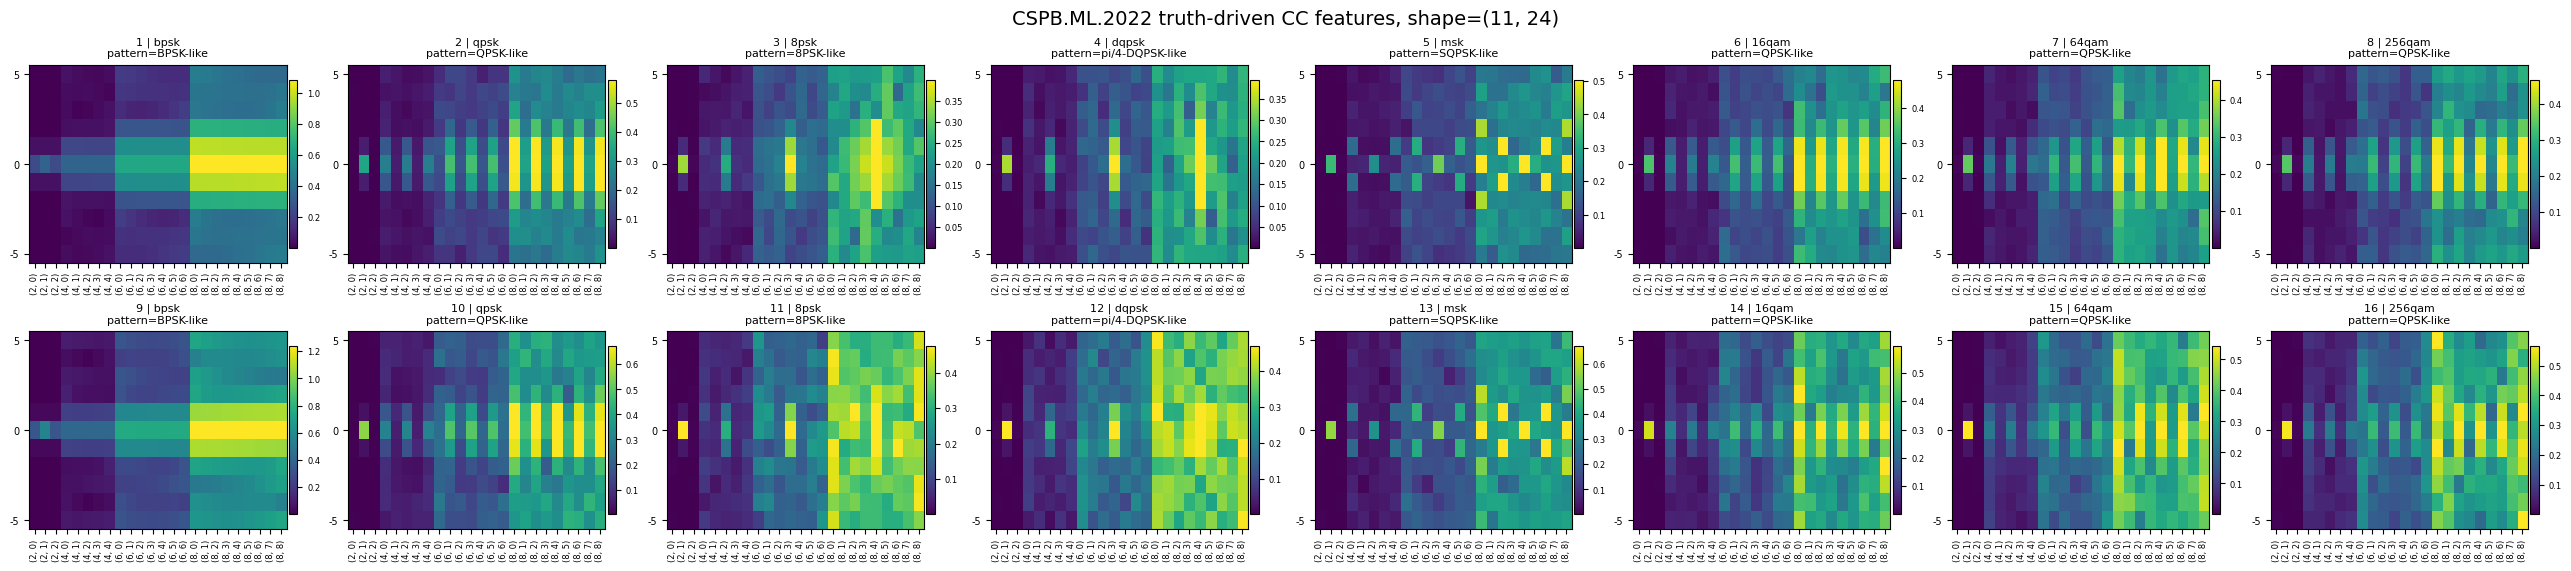

In [9]:
def extract_cc_feature_for_signal(signal_index: int):
    truth = get_truth_params(signal_index)
    tim_path, batch_dir = global_to_path_and_type(signal_index)
    x = tim_to_complex_iq_32768(tim_path)

    CC, meta = cc_11x24_estimates_truth_driven(
        x=x,
        T0=truth["T0"],
        f0=truth["f0"],
        max_k=MAX_K,
        remove_mean=REMOVE_MEAN,
        eps=EPS,
        blind_signal_power_scaling=True,
    )

    out = {
        "signal_index": signal_index,
        "batch_dir": batch_dir,
        "tim_path": tim_path,
        "signal_type": truth["signal_type"],
        "pattern_hint": truth["pattern_hint"],
        "T0": truth["T0"],
        "symbol_rate": truth["symbol_rate"],
        "f0": truth["f0"],
        "CC": CC,
        "meta": meta,
    }
    return out

def extract_many(signal_indices):
    feats = []
    fails = []

    for gidx in signal_indices:
        try:
            feats.append(extract_cc_feature_for_signal(gidx))
        except Exception as e:
            feats.append({
                "signal_index": gidx,
                "error": str(e),
                "CC": None
            })
            fails.append((gidx, str(e)))

    return feats, fails


def plot_feature_grid(feats, title=None, per_subplot_scale=True, qlow=0.02, qhigh=0.98):
    ok = [d["CC"] for d in feats if d.get("CC") is not None]
    if len(ok) == 0:
        raise RuntimeError("No valid CC features to plot.")

    rows = N_ROWS
    cols = N_COLS
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 2.8 * rows), constrained_layout=True)
    axes = np.array(axes).reshape(rows, cols)

    last_im = None
    last_meta = None

    for i in range(rows * cols):
        ax = axes.flat[i]
        if i >= len(feats):
            ax.axis("off")
            continue

        d = feats[i]
        if d.get("CC") is None:
            ax.axis("off")
            ax.set_title(f"{d['signal_index']} | FAIL", fontsize=9)
            ax.text(0.5, 0.5, d.get("error", ""), ha="center", va="center", fontsize=7, wrap=True)
            continue

        cc = d["CC"]
        meta = d["meta"]
        last_meta = meta

        if per_subplot_scale:
            vals = cc.reshape(-1)
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())
        else:
            vals = np.concatenate([x.reshape(-1) for x in ok])
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())

        im = ax.imshow(cc, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_title(
            f"{d['signal_index']} | {d['signal_type']}\n"
            f"pattern={d['pattern_hint']}",
            fontsize=8
        )

        # show a few xticks
        col_pairs = meta["col_pairs"]
        xt = np.arange(len(col_pairs))   
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [str(col_pairs[j]) for j in xt],
            fontsize=6,
            rotation=90
        )
        ks = meta["k"]
        yt = [0, len(ks)//2, len(ks)-1]
        ax.set_yticks(yt)
        ax.set_yticklabels([str(int(ks[j])) for j in yt], fontsize=7)
        if per_subplot_scale:
            cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
            cbar.ax.tick_params(labelsize=6)
    if (not per_subplot_scale) and (last_im is not None):
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.01)
        cbar.set_label("warped + USP-scaled |CC|", fontsize=10)

    if title is None:
        if last_meta is not None:
            title = f"CSPB.ML.{DATASET_NAME} truth-driven CC features, shape={last_meta['shape']}"
        else:
            title = f"CSPB.ML.{DATASET_NAME} truth-driven CC features"

    fig.suptitle(title, fontsize=14)
    plt.show()

signal_indices = list(range(INDEX_START, INDEX_START + N_ROWS * N_COLS))
feats, fails = extract_many(signal_indices)

print(f"Success: {sum(d.get('CC') is not None for d in feats)} / {len(feats)}")
if fails:
    print("Failures:")
    for g, msg in fails:
        print(f"  signal_{g}: {msg}")


plot_feature_grid(feats)

### Part1.10 Apply mask feature map to CC features based on the CF pattern.

Once the basic pattern of the signal is determined, some cycle frequencies will not need to be calculated, as shown in Figure 1 of Ref. 1. We can consider each basic pattern to have its unique mask. We hard-programmed the mask for each CF pattern from Figure 1 of Ref. 1 and simultaneously generated the 11×24 image shown in Figure 1 and the 11×15 image required for the CAP.

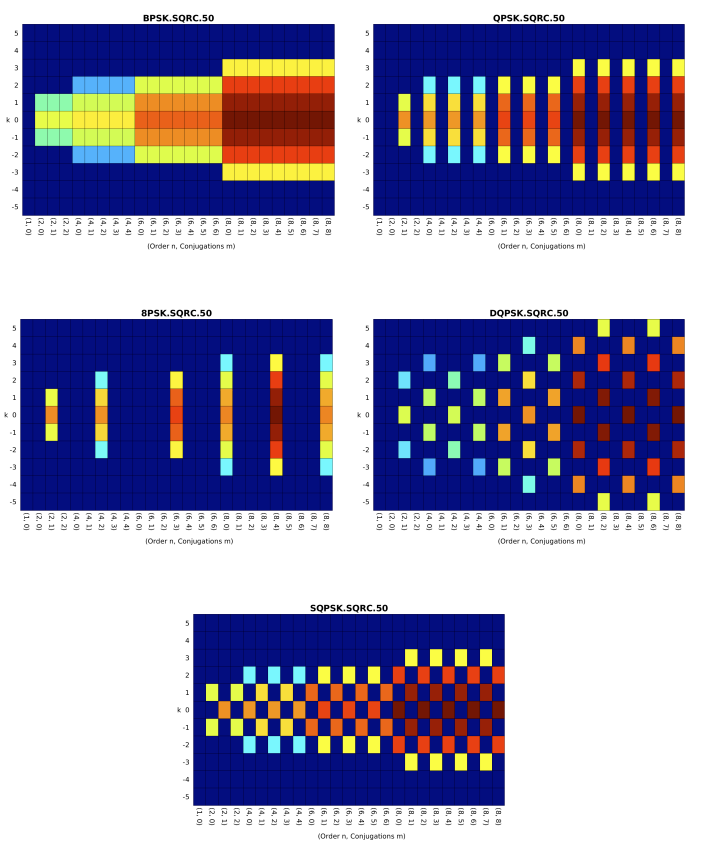

Success: 16 / 16


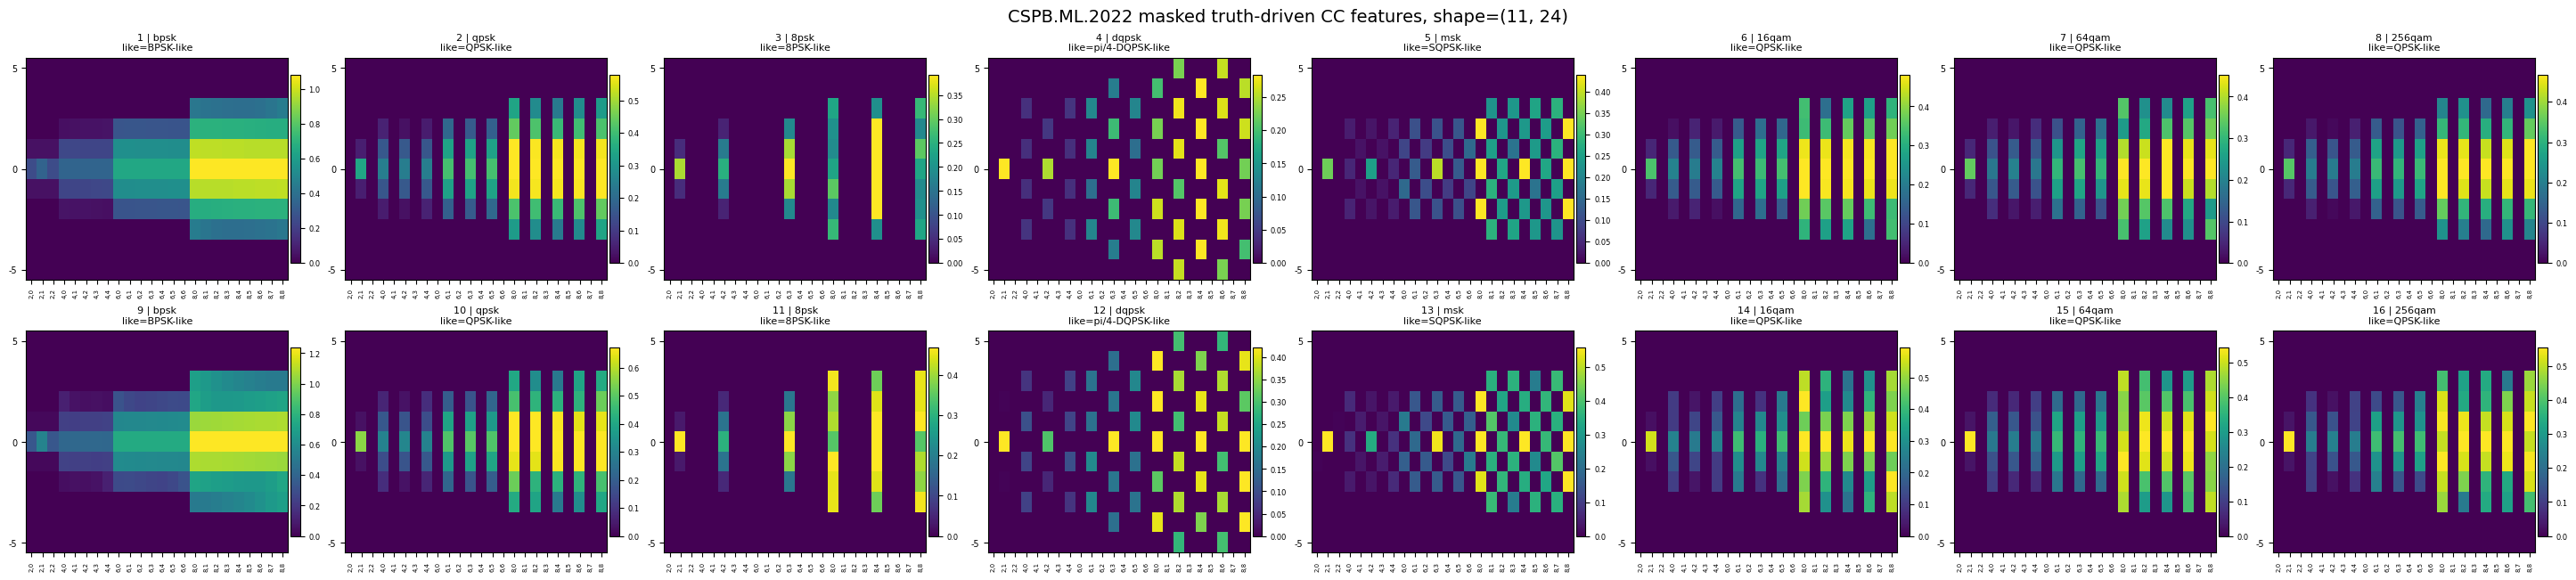

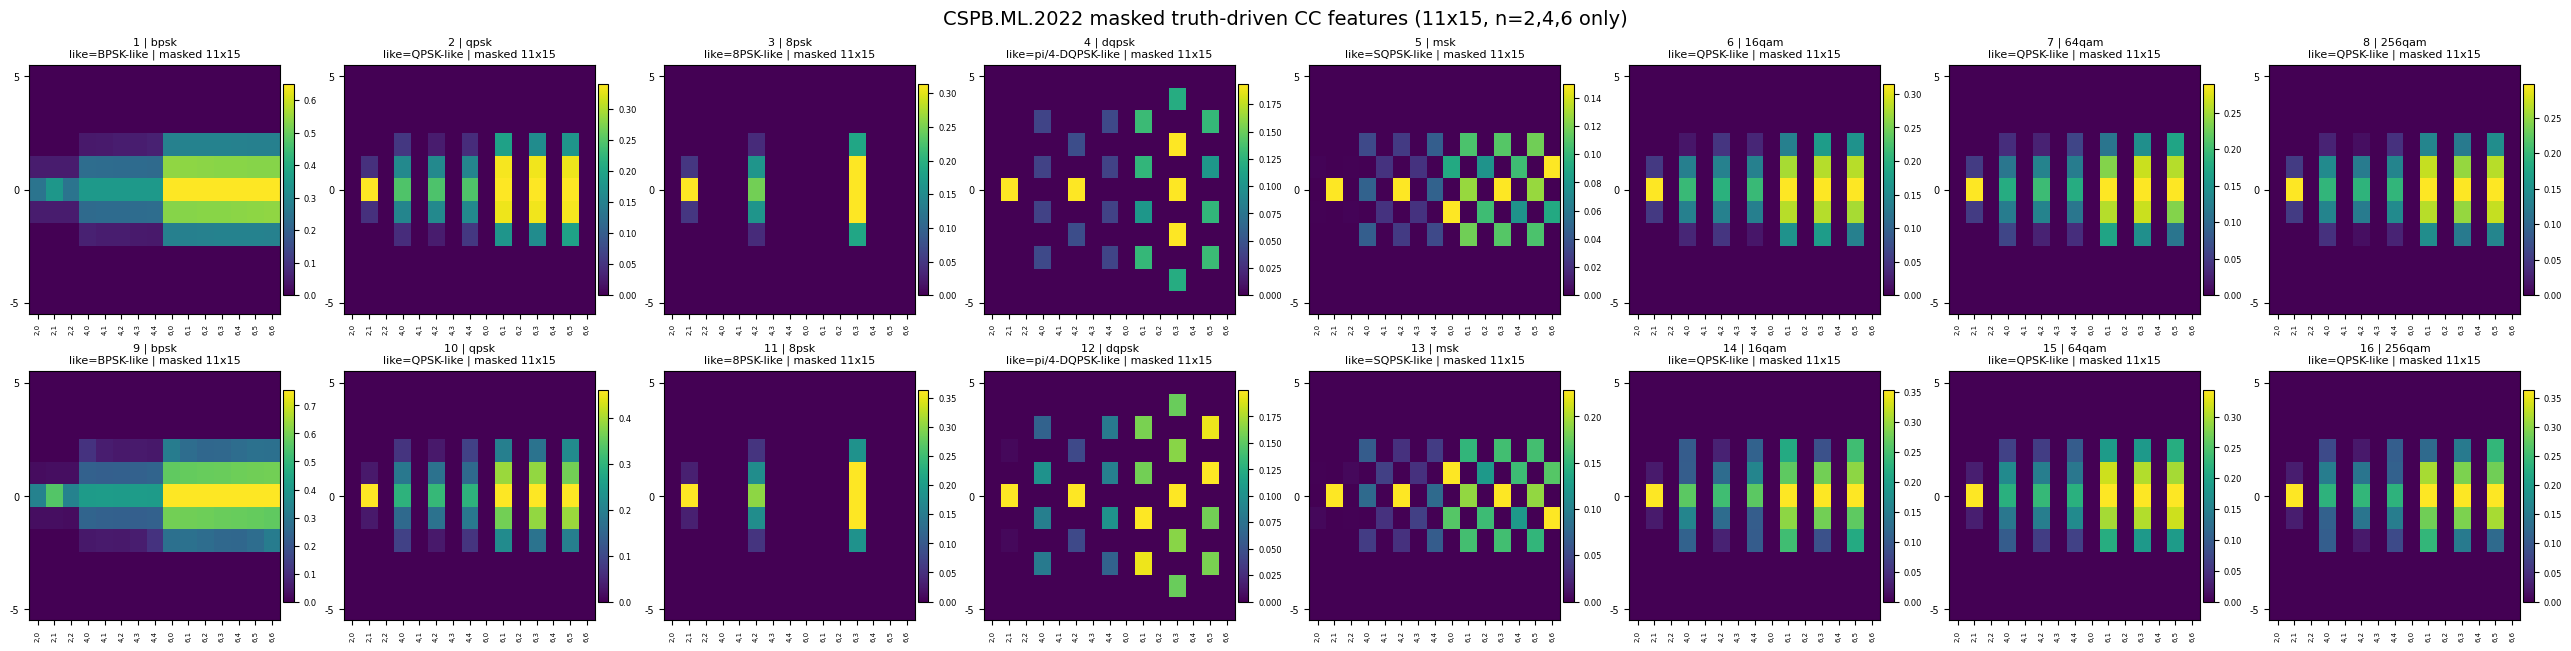

In [10]:
# ============================================================
# Build 11x24 binary masks from coordinate lists
# coords are (x, y), 0-based, image size = 24 x 11
# ============================================================
MASK_W = 24
MASK_H = 11
import numpy as np
import matplotlib.pyplot as plt

# =========================
# masks
# =========================
bpsk = [
    (0,4), (0,5), (0,6),
    (1,4), (1,5), (1,6),
    (2,4), (2,5), (2,6),
    (3,3), (3,4), (3,5), (3,6), (3,7),
    (4,3), (4,4), (4,5), (4,6), (4,7),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (6,3), (6,4), (6,5), (6,6), (6,7),
    (7,3), (7,4), (7,5), (7,6), (7,7),
    (8,3), (8,4), (8,5), (8,6), (8,7),
    (9,3), (9,4), (9,5), (9,6), (9,7),
    (10,3), (10,4), (10,5), (10,6), (10,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (12,3), (12,4), (12,5), (12,6), (12,7),
    (13,3), (13,4), (13,5), (13,6), (13,7),
    (14,3), (14,4), (14,5), (14,6), (14,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (16,2), (16,3), (16,4), (16,5), (16,6), (16,7), (16,8),
    (17,2), (17,3), (17,4), (17,5), (17,6), (17,7), (17,8),
    (18,2), (18,3), (18,4), (18,5), (18,6), (18,7), (18,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (20,2), (20,3), (20,4), (20,5), (20,6), (20,7), (20,8),
    (21,2), (21,3), (21,4), (21,5), (21,6), (21,7), (21,8),
    (22,2), (22,3), (22,4), (22,5), (22,6), (22,7), (22,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

qpsk = [
    (1,4), (1,5), (1,6),
    (3,3), (3,4), (3,5), (3,6), (3,7),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (7,3), (7,4), (7,5), (7,6), (7,7),
    (9,3), (9,4), (9,5), (9,6), (9,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (13,3), (13,4), (13,5), (13,6), (13,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (17,2), (17,3), (17,4), (17,5), (17,6), (17,7), (17,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (21,2), (21,3), (21,4), (21,5), (21,6), (21,7), (21,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

psk8 = [
    (1,4), (1,5), (1,6),
    (5,3), (5,4), (5,5), (5,6), (5,7),
    (11,3), (11,4), (11,5), (11,6), (11,7),
    (15,2), (15,3), (15,4), (15,5), (15,6), (15,7), (15,8),
    (19,2), (19,3), (19,4), (19,5), (19,6), (19,7), (19,8),
    (23,2), (23,3), (23,4), (23,5), (23,6), (23,7), (23,8),
]

dqpsk = [
    (1,3), (1,5), (1,7),
    (3,2), (3,4), (3,6), (3,8),
    (5,3), (5,5), (5,7),
    (7,2), (7,4), (7,6), (7,8),
    (9,2), (9,4), (9,6), (9,8),
    (11,1), (11,3), (11,5), (11,7), (11,9),
    (13,2), (13,4), (13,6), (13,8),
    (15,1), (15,3), (15,5), (15,7), (15,9),
    (17,0), (17,2), (17,4), (17,6), (17,8), (17,10),
    (19,1), (19,3), (19,5), (19,7), (19,9),
    (21,0), (21,2), (21,4), (21,6), (21,8), (21,10),
    (23,1), (23,3), (23,5), (23,7), (23,9),
]

sqpsk = [
    (0,4), (0,6),
    (1,5),
    (2,4), (2,6),
    (3,3), (3,5), (3,7),
    (4,4), (4,6),
    (5,3), (5,5), (5,7),
    (6,4), (6,6),
    (7,3), (7,5), (7,7),
    (8,4), (8,6),
    (9,3), (9,5), (9,7),
    (10,4), (10,6),
    (11,3), (11,5), (11,7),
    (12,4), (12,6),
    (13,3), (13,5), (13,7),
    (14,4), (14,6),
    (15,3), (15,5), (15,7),
    (16,2), (16,4), (16,6), (16,8),
    (17,3), (17,5), (17,7),
    (18,2), (18,4), (18,6), (18,8),
    (19,3), (19,5), (19,7),
    (20,2), (20,4), (20,6), (20,8),
    (21,3), (21,5), (21,7),
    (22,2), (22,4), (22,6), (22,8),
    (23,3), (23,5), (23,7),
]

def coords_to_mask(coords, width=MASK_W, height=MASK_H):
    mask = np.zeros((height, width), dtype=np.float64)
    for x, y in coords:
        if 0 <= x < width and 0 <= y < height:
            mask[y, x] = 1.0
    return mask

MASK_BPSK  = coords_to_mask(bpsk)
MASK_QPSK  = coords_to_mask(qpsk)
MASK_8PSK  = coords_to_mask(psk8)
MASK_DQPSK = coords_to_mask(dqpsk)
MASK_SQPSK = coords_to_mask(sqpsk)

MASK_BY_LIKE = {
    "BPSK-like": MASK_BPSK,
    "QPSK-like": MASK_QPSK,
    "8PSK-like": MASK_8PSK,
    "pi/4-DQPSK-like": MASK_DQPSK,
    "SQPSK-like": MASK_SQPSK,
}

def signal_type_to_like_name(sig_type: str) -> str:
    sig_type = str(sig_type).lower()
    if sig_type == "bpsk":
        return "BPSK-like"
    elif sig_type == "qpsk":
        return "QPSK-like"
    elif sig_type == "8psk":
        return "8PSK-like"
    elif sig_type == "dqpsk":
        return "pi/4-DQPSK-like"
    elif sig_type == "msk":
        return "SQPSK-like"
    elif sig_type in {"16qam", "64qam", "256qam"}:
        return "QPSK-like"
    else:
        return None

def get_mask_for_signal_type(sig_type: str):
    like_name = signal_type_to_like_name(sig_type)
    if like_name is None:
        return np.ones((MASK_H, MASK_W), dtype=np.float64), "Unknown"
    return MASK_BY_LIKE[like_name], like_name

def crop_masked_11x24_to_11x15(cc_masked, meta):
    cc_11x15 = cc_masked[:, :15]
    col_pairs_11x15 = meta["col_pairs"][:15]
    return cc_11x15, col_pairs_11x15

def plot_feature_grid_masked_11x15(feats, title=None, per_subplot_scale=True, qlow=0.02, qhigh=0.98):
    ok = []
    for d in feats:
        if d.get("CC") is not None:
            mask, like_name = get_mask_for_signal_type(d["signal_type"])
            cc_masked = d["CC"] * mask
            cc_11x15, _ = crop_masked_11x24_to_11x15(cc_masked, d["meta"])
            ok.append(cc_11x15)

    if len(ok) == 0:
        raise RuntimeError("No valid CC features to plot.")

    rows = N_ROWS
    cols = N_COLS
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows), constrained_layout=True)
    axes = np.array(axes).reshape(rows, cols)

    last_im = None
    last_meta = None

    for i in range(rows * cols):
        ax = axes.flat[i]
        if i >= len(feats):
            ax.axis("off")
            continue

        d = feats[i]
        if d.get("CC") is None:
            ax.axis("off")
            ax.set_title(f"{d['signal_index']} | FAIL", fontsize=9)
            ax.text(0.5, 0.5, d.get("error", ""), ha="center", va="center", fontsize=7, wrap=True)
            continue

        cc = d["CC"]
        meta = d["meta"]
        last_meta = meta

        mask, like_name = get_mask_for_signal_type(d["signal_type"])
        cc_masked = cc * mask
        cc_11x15, col_pairs_11x15 = crop_masked_11x24_to_11x15(cc_masked, meta)

        if per_subplot_scale:
            vals = cc_11x15.reshape(-1)
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())
        else:
            vals = np.concatenate([x.reshape(-1) for x in ok])
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())

        im = ax.imshow(cc_11x15, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_title(
            f"{d['signal_index']} | {d['signal_type']}\n"
            f"like={like_name} | masked 11x15",
            fontsize=8
        )

        xt = np.arange(len(col_pairs_11x15))
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [f"{n},{m}" for (n, m) in col_pairs_11x15],
            fontsize=5,
            rotation=90
        )

        ks = meta["k"]
        yt = [0, len(ks)//2, len(ks)-1]
        ax.set_yticks(yt)
        ax.set_yticklabels([str(int(ks[j])) for j in yt], fontsize=7)

        if per_subplot_scale:
            cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
            cbar.ax.tick_params(labelsize=6)

    if (not per_subplot_scale) and (last_im is not None):
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.01)
        cbar.set_label("masked warped + USP-scaled |CC| (n=2,4,6 only)", fontsize=10)

    if title is None:
        title = f"CSPB.ML.{DATASET_NAME} masked truth-driven CC features (11x15, n=2,4,6 only)"

    fig.suptitle(title, fontsize=14)
    plt.show()

def plot_feature_grid_masked(feats, title=None, per_subplot_scale=True, qlow=0.02, qhigh=0.98):
    ok = []
    for d in feats:
        if d.get("CC") is not None:
            mask, like_name = get_mask_for_signal_type(d["signal_type"])
            ok.append(d["CC"] * mask)

    if len(ok) == 0:
        raise RuntimeError("No valid CC features to plot.")

    rows = N_ROWS
    cols = N_COLS
    fig, axes = plt.subplots(rows, cols, figsize=(3.6 * cols, 3.2 * rows), constrained_layout=True)
    axes = np.array(axes).reshape(rows, cols)

    last_im = None
    last_meta = None

    for i in range(rows * cols):
        ax = axes.flat[i]
        if i >= len(feats):
            ax.axis("off")
            continue

        d = feats[i]
        if d.get("CC") is None:
            ax.axis("off")
            ax.set_title(f"{d['signal_index']} | FAIL", fontsize=9)
            ax.text(0.5, 0.5, d.get("error", ""), ha="center", va="center", fontsize=7, wrap=True)
            continue

        cc = d["CC"]
        meta = d["meta"]
        last_meta = meta

        mask, like_name = get_mask_for_signal_type(d["signal_type"])
        cc_masked = cc * mask

        if per_subplot_scale:
            vals = cc_masked.reshape(-1)
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())
        else:
            vals = np.concatenate([x.reshape(-1) for x in ok])
            vmin = np.quantile(vals, qlow)
            vmax = np.quantile(vals, qhigh)
            if vmax <= vmin:
                vmin = float(vals.min())
                vmax = float(vals.max())

        im = ax.imshow(cc_masked, aspect="auto", origin="lower", vmin=vmin, vmax=vmax)
        last_im = im

        ax.set_title(
            f"{d['signal_index']} | {d['signal_type']}\n"
            f"like={like_name}",
            fontsize=8
        )

        col_pairs = meta["col_pairs"]
        xt = np.arange(len(col_pairs))
        ax.set_xticks(xt)
        ax.set_xticklabels(
            [f"{n},{m}" for (n, m) in col_pairs],
            fontsize=5,
            rotation=90
        )

        ks = meta["k"]
        yt = [0, len(ks)//2, len(ks)-1]
        ax.set_yticks(yt)
        ax.set_yticklabels([str(int(ks[j])) for j in yt], fontsize=7)

        if per_subplot_scale:
            cbar = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.01)
            cbar.ax.tick_params(labelsize=6)

    if (not per_subplot_scale) and (last_im is not None):
        cbar = fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.9, pad=0.01)
        cbar.set_label("masked warped + USP-scaled |CC|", fontsize=10)

    if title is None:
        if last_meta is not None:
            title = f"CSPB.ML.{DATASET_NAME} masked truth-driven CC features, shape={last_meta['shape']}"
        else:
            title = f"CSPB.ML.{DATASET_NAME} masked truth-driven CC features"

    fig.suptitle(title, fontsize=14)
    plt.show()

# ============================================================
# Run
# ============================================================
N_ROWS = 2
N_COLS = 8

print(f"Success: {sum(d.get('CC') is not None for d in feats)} / {len(feats)}")
if fails:
    print("Failures:")
    for g, msg in fails:
        print(f"  signal_{g}: {msg}")

plot_feature_grid_masked(feats)
plot_feature_grid_masked_11x15(feats)  # 再看论文口径 11x15

### Part1.11 CC feature dataset generation (optional)

In [11]:
'''
import os
import gc
import time
import numpy as np
import torch
from tqdm import tqdm

# ----------------------------
# Config
# ----------------------------
# DATASET_NAME = "2022"   # "2022" or "2018"

ROOT_MAP = {
    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",
    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",
}

OUT_BASE = "../../../CC_feature"

KMAX = 5
L = 2 * KMAX + 1

N_BATCHES = 28
N_PER_DIR = 4000
N_TOTAL = N_BATCHES * N_PER_DIR

classes = ['BPSK','QPSK','8PSK','DQPSK','MSK','16QAM','64QAM','256QAM']

if DATASET_NAME not in ROOT_MAP:
    raise ValueError(f"Unsupported DATASET_NAME: {DATASET_NAME}")

ROOT_TIM = ROOT_MAP[DATASET_NAME]


def create_label():
    base = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.long)
    return base.repeat(500).reshape(-1, 1)


def process_one_dir(batch_idx: int):
    in_dir = os.path.join(ROOT_TIM, f"Batch_Dir_{batch_idx}")

    X = torch.empty((N_PER_DIR, 11, 24), dtype=torch.float32)
    y = create_label()

    failed = 0

    for n in tqdm(range(1, N_PER_DIR + 1), desc=f"{DATASET_NAME} Batch {batch_idx:02d}", ncols=100):
        gidx = (batch_idx - 1) * N_PER_DIR + n
        tim_path = os.path.join(in_dir, f"signal_{gidx}.tim")

        try:
            x = tim_to_complex_iq_32768(tim_path)
            truth = get_truth_params(gidx)

            cc_mat, meta = cc_11x24_estimates_truth_driven(
                x=x,
                T0=truth["T0"],
                f0=truth["f0"],
                max_k=KMAX,
                remove_mean=False,
                eps=1e-12,
                blind_signal_power_scaling=True,
            )

            if cc_mat.shape != (11, 24):
                raise ValueError(
                    f"signal_{gidx}: got CC shape {cc_mat.shape}, expected (11,24)"
                )

            mask, like_name = get_mask_for_signal_type(truth["signal_type"])
            cc_masked = cc_mat * mask

            X[n - 1].copy_(torch.from_numpy(cc_masked.astype(np.float32)))

        except Exception as e:
            X[n - 1].zero_()
            failed += 1
            print(f"[WARN] {DATASET_NAME} signal_{gidx} failed: {e}")

    out_dir = os.path.join(
        OUT_BASE,
        f"{DATASET_NAME}_cc_truthdriven_KMAX{KMAX}_11x24_masked_test"
    )
    os.makedirs(out_dir, exist_ok=True)

    out_path = os.path.join(out_dir, f"{DATASET_NAME}_batch_{batch_idx:02d}.pt")

    torch.save((X, y), out_path)
    print(f"saved {out_path} | X {tuple(X.shape)} y {tuple(y.shape)} | failed={failed}")

    del X, y
    gc.collect()


if __name__ == "__main__":
    t0 = time.time()

    START_BATCH = 1
    END_BATCH = 28

    for idx in range(START_BATCH, END_BATCH + 1):
        process_one_dir(idx)

    print(f"{DATASET_NAME} all finished in {(time.time() - t0)/60:.2f} min")

'''

'\nimport os\nimport gc\nimport time\nimport numpy as np\nimport torch\nfrom tqdm import tqdm\n\n# ----------------------------\n# Config\n# ----------------------------\n# DATASET_NAME = "2022"   # "2022" or "2018"\n\nROOT_MAP = {\n    "2022": "../../../CSPB.ML_dataset/CSPB_ML_2022_Data",\n    "2018": "../../../CSPB.ML_dataset/CSPB_ML_2018_Data",\n}\n\nOUT_BASE = "../../../CC_feature"\n\nKMAX = 5\nL = 2 * KMAX + 1\n\nN_BATCHES = 28\nN_PER_DIR = 4000\nN_TOTAL = N_BATCHES * N_PER_DIR\n\nclasses = [\'BPSK\',\'QPSK\',\'8PSK\',\'DQPSK\',\'MSK\',\'16QAM\',\'64QAM\',\'256QAM\']\n\nif DATASET_NAME not in ROOT_MAP:\n    raise ValueError(f"Unsupported DATASET_NAME: {DATASET_NAME}")\n\nROOT_TIM = ROOT_MAP[DATASET_NAME]\n\n\ndef create_label():\n    base = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7], dtype=torch.long)\n    return base.repeat(500).reshape(-1, 1)\n\n\ndef process_one_dir(batch_idx: int):\n    in_dir = os.path.join(ROOT_TIM, f"Batch_Dir_{batch_idx}")\n\n    X = torch.empty((N_PER_DIR, 11,

## Part2 CAP training 

### Part2.1 Dataset partitioning

The variable `TRAIN_SET` chooses which dataset is used as the **source domain** for model development:

- `"2022"`: train/validate/test on CSPB.ML.2022
- `"2018"`: train/validate/test on CSPB.ML.2018

For the chosen training dataset, the 28 batch files are split as follows:

- **Training set**: batches `01–10` and `19–28`
- **Validation set**: batches `11–14`
- **Test set**: batches `15–18`

So the source-domain split is:

- 20 batches for training
- 4 batches for validation
- 4 batches for in-domain testing

In addition to the in-domain split above, the code also defines an **external test set**:

- if training on `"2022"`, the external test set is **all 28 batches of 2018**
- if training on `"2018"`, the external test set is **all 28 batches of 2022**

In [12]:
import os, math, random, time
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# optional
from sklearn.metrics import confusion_matrix, accuracy_score

# =========================
# Paths (EDIT THESE)
# =========================
PT_DIR_2022 = Path("../../../CC_feature/2022_cc_truthdriven_KMAX5_11x24_masked_test")
PT_DIR_2018 = Path("../../../CC_feature/2018_cc_truthdriven_KMAX5_11x24_masked_test")

PREFIX_2022 = "2022_batch_"
PREFIX_2018 = "2018_batch_"

N_BATCHES = 28

def list_pt_files(pt_dir: Path, prefix: str, n_batches=28):
    return [pt_dir / f"{prefix}{i:02d}.pt" for i in range(1, n_batches + 1)]

# =========================
# Choose which dataset to TRAIN on: "2022" or "2018"
# =========================
TRAIN_SET = "2022"   # "2022" or "2018"

pt_files = {
    "2022": list_pt_files(PT_DIR_2022, PREFIX_2022, N_BATCHES),
    "2018": list_pt_files(PT_DIR_2018, PREFIX_2018, N_BATCHES),
}

missing_2022 = [str(p) for p in pt_files["2022"] if not p.exists()]
missing_2018 = [str(p) for p in pt_files["2018"] if not p.exists()]

print("missing_2022:", len(missing_2022))
print("missing_2018:", len(missing_2018))

# =========================
# Split rule (temporarily unchanged)
# =========================
def make_splits(train_set: str):
    assert train_set in ("2022", "2018")
    other_set = "2018" if train_set == "2022" else "2022"

    train_files = pt_files[train_set][:10] + pt_files[train_set][-10:]
    val_files   = pt_files[train_set][10:14]
    test_files  = pt_files[train_set][14:18]
    ext_files   = pt_files[other_set][:]

    return train_set, other_set, train_files, val_files, test_files, ext_files

TRAIN_SET_NAME, EXT_SET_NAME, train_files, val_files, test_files, ext_files = make_splits(TRAIN_SET)

print("TRAIN on:", TRAIN_SET_NAME)
print("External test on:", EXT_SET_NAME)
print(f"{TRAIN_SET_NAME} train:", [p.name for p in train_files])
print(f"{TRAIN_SET_NAME} val  :", [p.name for p in val_files])
print(f"{TRAIN_SET_NAME} test :", [p.name for p in test_files])
print(f"{EXT_SET_NAME} test   :", [p.name for p in ext_files])

class PTConcatDataset(Dataset):
    """
    Loads multiple .pt files that each store (X, y).
    X expected shape: (N, H, W) or (N, 1, H, W)
    y expected shape: (N,1) or (N,)
    Minimal paper-aligned modification:
      - crop X from 11x24 to 11x15 by keeping the first 15 columns
    """
    def __init__(self, pt_files, keep_first_15_cols=True):
        self.pt_files = list(pt_files)
        self.keep_first_15_cols = keep_first_15_cols

        self.X_list = []
        self.y_list = []
        self._load_all()

        self.X = torch.cat(self.X_list, dim=0)
        self.y = torch.cat(self.y_list, dim=0)
        del self.X_list, self.y_list

        if self.X.ndim == 3:
            self.X = self.X.unsqueeze(1)   # (N,1,H,W)
        elif self.X.ndim == 4:
            pass
        else:
            raise ValueError(f"Unexpected X dim: {self.X.shape}")

        if self.y.ndim == 2:
            self.y = self.y.squeeze(1)
        self.y = self.y.long()

        self.N, self.C, self.H, self.W = self.X.shape

    def _load_all(self):
        for p in self.pt_files:
            X, y = torch.load(p, map_location="cpu")
            X = X.float()

            if y is None:
                raise ValueError(f"{p} has y=None; expected labels.")

            self.X_list.append(X)
            self.y_list.append(y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        X = self.X[idx]    # (1,H,W) or (C,H,W)
        y = self.y[idx]

        # paper-aligned input: 11 x 15
        if self.keep_first_15_cols:
            if X.shape[-2] != 11:
                raise ValueError(f"Expected height 11, got {X.shape}")
            if X.shape[-1] < 15:
                raise ValueError(f"Expected width >= 15, got {X.shape}")
            X = X[..., :15]

        return X, y

ds_train = PTConcatDataset(train_files, keep_first_15_cols=True)
ds_val   = PTConcatDataset(val_files,   keep_first_15_cols=True)
ds_test  = PTConcatDataset(test_files,  keep_first_15_cols=True)
ds_ext   = PTConcatDataset(ext_files,   keep_first_15_cols=True)

print("Train raw shape:", ds_train.X.shape, ds_train.y.shape)
X0, y0 = ds_train[0]
print("One sample after crop:", X0.shape, y0, "min/max", float(X0.min()), float(X0.max()))

missing_2022: 0
missing_2018: 0
TRAIN on: 2022
External test on: 2018
2022 train: ['2022_batch_01.pt', '2022_batch_02.pt', '2022_batch_03.pt', '2022_batch_04.pt', '2022_batch_05.pt', '2022_batch_06.pt', '2022_batch_07.pt', '2022_batch_08.pt', '2022_batch_09.pt', '2022_batch_10.pt', '2022_batch_19.pt', '2022_batch_20.pt', '2022_batch_21.pt', '2022_batch_22.pt', '2022_batch_23.pt', '2022_batch_24.pt', '2022_batch_25.pt', '2022_batch_26.pt', '2022_batch_27.pt', '2022_batch_28.pt']
2022 val  : ['2022_batch_11.pt', '2022_batch_12.pt', '2022_batch_13.pt', '2022_batch_14.pt']
2022 test : ['2022_batch_15.pt', '2022_batch_16.pt', '2022_batch_17.pt', '2022_batch_18.pt']
2018 test   : ['2018_batch_01.pt', '2018_batch_02.pt', '2018_batch_03.pt', '2018_batch_04.pt', '2018_batch_05.pt', '2018_batch_06.pt', '2018_batch_07.pt', '2018_batch_08.pt', '2018_batch_09.pt', '2018_batch_10.pt', '2018_batch_11.pt', '2018_batch_12.pt', '2018_batch_13.pt', '2018_batch_14.pt', '2018_batch_15.pt', '2018_batch_16.p

/tmp/ipykernel_4143164/2391992900.py:99: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X, y = torch.load(p, map_location="cpu")


Train raw shape: torch.Size([80000, 1, 11, 24]) torch.Size([80000])
One sample after crop: torch.Size([1, 11, 15]) tensor(0) min/max 0.0 0.6513906717300415


### Part2.2 CAP and hyperparameter



This implementation follows the **CC-trained CAP classifier** described in the paper. The network takes a **11 × 15 × 1** CC feature map as input and performs classification over **eight modulation classes** using **eight parallel branches**. The paper describes a shared feature-extraction layer followed by eight class-specific branches whose outputs are combined into an 8-dimensional vector for final classification. 

In the code, the shared front-end is implemented in `CAPNetPaper`. It uses a convolution from **1 to 56 channels** with kernel **(6, 4)** and stride **(1, 2)**, followed by BatchNorm and `tanh`, matching the paper’s feature-extraction block. 
Each branch is implemented in `CAPBranchPaper`. It contains:

- Conv: **56 filters**, kernel **(4, 4)**, stride **(1, 2)**  
- BatchNorm + `tanh`
- Conv: **72 filters**, kernel **(4, 6)**, stride **(1, 2)**  
- BatchNorm + `tanh`
- FC: **7**
- BatchNorm + `relu`
- Point FC: **1**

This matches the branch layout reported in the paper’s Table 1. 

The code uses `SameConv2d` to preserve the intended spatial sizes under stride `(1, 2)`. For an input of **11 × 15**, the feature sizes become:

- shared block: `11 × 15 -> 11 × 8`
- branch conv1: `11 × 8 -> 11 × 4`
- branch conv2: `11 × 4 -> 11 × 2`

So the flattened dimension inside each branch is `72 × 11 × 2 = 1584`, which is the input size of the first fully connected layer. 

At the top level, `CAPNetPaper` builds **eight identical branches** and concatenates their outputs into a tensor of shape `(batch_size, 8)`, corresponding to the paper’s final 8-dimensional class vector.


The paper states that the CC-trained CAP is trained with **Adam** for **10 epochs**, using **batch size 250**, **learning rate 0.001**, **weight decay 0.0001**, **betas (0.9, 0.999)**, **epsilon 1e-8**, and a **piecewise learning schedule** that multiplies the learning rate by **0.9 every 5 epochs**. It also states that the training data are shuffled before each epoch. 
The code follows these settings directly:

- `BATCH_SIZE = 250`
- `EPOCHS = 10`
- `LR = 1e-3`
- `WEIGHT_DECAY = 1e-4`
- `BETAS = (0.9, 0.999)`
- `EPS = 1e-8`

The optimizer is `torch.optim.Adam`, and the scheduler is `StepLR(step_size=5, gamma=0.9)`, which matches the paper’s learning-rate schedule. 

The training dataloader uses `shuffle=True`, consistent with the paper’s statement that data are shuffled before each epoch. The loss function is `CrossEntropyLoss`, applied to the 8-class logits. 

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def _same_pad_2d(x, kernel_size, stride=(1,1), dilation=(1,1)):
    """
    Dynamic SAME padding for 2D conv.
    Works with stride != 1.
    """
    if isinstance(kernel_size, int):
        kh, kw = kernel_size, kernel_size
    else:
        kh, kw = kernel_size

    sh, sw = stride
    dh, dw = dilation

    in_h, in_w = x.shape[-2], x.shape[-1]

    eff_kh = (kh - 1) * dh + 1
    eff_kw = (kw - 1) * dw + 1

    out_h = (in_h + sh - 1) // sh
    out_w = (in_w + sw - 1) // sw

    pad_h = max(0, (out_h - 1) * sh + eff_kh - in_h)
    pad_w = max(0, (out_w - 1) * sw + eff_kw - in_w)

    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    return F.pad(x, (pad_left, pad_right, pad_top, pad_bottom))


class SameConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, stride=(1,1), dilation=(1,1), bias=False):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride
        self.dilation = dilation
        self.conv = nn.Conv2d(
            in_ch, out_ch,
            kernel_size=kernel_size,
            stride=stride,
            padding=0,
            dilation=dilation,
            bias=bias
        )

    def forward(self, x):
        x = _same_pad_2d(x, self.kernel_size, self.stride, self.dilation)
        return self.conv(x)


class CAPBranchPaper(nn.Module):
    """
    Paper-faithful branch structure:
      Conv-1-(i): 56 filters, kernel 4x4, stride 1x2
      BN -> Tanh
      Conv-2-(i): 72 filters, kernel 4x6, stride 1x2
      BN -> Tanh
      FC-(i): 7
      BN -> ReLU
      Point FC-(i): 1
    """
    def __init__(self, in_ch=56):
        super().__init__()

        self.conv1 = SameConv2d(in_ch, 56, kernel_size=(4, 4), stride=(1, 2), bias=False)
        self.bn1   = nn.BatchNorm2d(56)

        self.conv2 = SameConv2d(56, 72, kernel_size=(4, 6), stride=(1, 2), bias=False)
        self.bn2   = nn.BatchNorm2d(72)

        # for input 11x15, SAME-style sizes become:
        # shared: 11x15 -> 11x8
        # conv1 : 11x8  -> 11x4
        # conv2 : 11x4  -> 11x2
        # so flatten dim = 72 * 11 * 2 = 1584
        self.fc1 = nn.Linear(72 * 11 * 2, 7, bias=False)
        self.bn3 = nn.BatchNorm1d(7)
        self.fc2 = nn.Linear(7, 1, bias=True)

    def forward(self, x):
        x = torch.tanh(self.bn1(self.conv1(x)))
        x = torch.tanh(self.bn2(self.conv2(x)))

        # debug once if needed
        # print("branch feature shape:", x.shape)

        x = x.flatten(1)
        x = torch.relu(self.bn3(self.fc1(x)))
        x = self.fc2(x)
        return x


class CAPNetPaper(nn.Module):
    """
    Paper Table 1:
      Input: 11 x 15 x 1
      Feature extraction:
        Conv (56), kernel 6x4, stride 1x2
        BN
        Tanh
      Then 8 branches
    """
    def __init__(self, n_classes=8):
        super().__init__()
        self.n_classes = n_classes

        self.shared_conv = SameConv2d(1, 56, kernel_size=(6, 4), stride=(1, 2), bias=False)
        self.shared_bn   = nn.BatchNorm2d(56)

        self.branches = nn.ModuleList([
            CAPBranchPaper(in_ch=56) for _ in range(n_classes)
        ])

    def forward(self, x):
        x = torch.tanh(self.shared_bn(self.shared_conv(x)))

        # debug once if needed
        # print("shared feature shape:", x.shape)

        logits = [br(x) for br in self.branches]
        return torch.cat(logits, dim=1)


# ============================================================
# Utilities
# ============================================================
def count_params(model: nn.Module):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_report(model: nn.Module, name="model"):
    n = count_params(model)
    mb = n * 4 / (1024 ** 2)
    print(f"[{name}] trainable params: {n:,d}")
    print(f"[{name}] approx param size: {mb:.2f} MB (fp32, params only)")

@torch.no_grad()
def eval_one(model, loader, device, criterion):
    model.eval()
    ys = []
    ps = []
    losses = []

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        loss = criterion(logits, y)

        losses.append(loss.item())
        pred = logits.argmax(dim=1)
        ys.append(y.cpu())
        ps.append(pred.cpu())

    y_true = torch.cat(ys).numpy()
    y_pred = torch.cat(ps).numpy()
    acc = accuracy_score(y_true, y_pred)
    return float(np.mean(losses)), float(acc), y_true, y_pred

def train_one_epoch(model, loader, optimizer, device, criterion):
    model.train()
    losses = []
    correct = 0
    total = 0

    for X, y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.numel()

    return float(np.mean(losses)), float(correct / total)

def _fmt(loss, acc):
    return f"{loss:.4f}/{acc*100:5.2f}%"


# ============================================================
# Device
# ============================================================
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

# ============================================================
# Paper hyperparameters from Snoap 2023
# ============================================================
BATCH_SIZE = 250
NUM_WORKERS = 4

EPOCHS = 10
LR = 1e-3
WEIGHT_DECAY = 1e-4   # L2 regularization factor
BETAS = (0.9, 0.999)
EPS = 1e-8

# ============================================================
# Dataloaders
# Note: split rule currently unchanged, per your request
# ds_train / ds_val / ds_test / ds_ext come from Pasted code (2).py
# ============================================================
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
ext_test_loader = DataLoader(ds_ext, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

# ============================================================
# Model
# ============================================================
model = CAPNetPaper(n_classes=8).to(DEVICE)
print_model_report(model, name="CAPNetPaper")

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    betas=BETAS,
    eps=EPS,
    weight_decay=WEIGHT_DECAY
)

# piecewise learning schedule: multiply by 0.9 every 5 epochs
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.9
)

# ============================================================
# Train
# ============================================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "test_loss": [],
    "test_acc": [],
    "ext_loss": [],
    "ext_acc": [],
}

SAVE_DIR = Path("./capnet_ckpt_paper_like")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MODEL_PATH = SAVE_DIR / f"final_{TRAIN_SET_NAME}_capnet_paper_like.pt"

t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    # paper says shuffle before each epoch -> already handled by DataLoader(shuffle=True)
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, DEVICE, criterion)
    va_loss, va_acc, _, _ = eval_one(model, val_loader, DEVICE, criterion)
    te_loss, te_acc, _, _ = eval_one(model, test_loader, DEVICE, criterion)
    ext_loss, ext_acc, _, _ = eval_one(model, ext_test_loader, DEVICE, criterion)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
    history["ext_loss"].append(ext_loss)
    history["ext_acc"].append(ext_acc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch {epoch:03d} | lr {lr_now:.2e} | "
        f"train {_fmt(tr_loss, tr_acc)} | "
        f"val {_fmt(va_loss, va_acc)} | "
        f"test({TRAIN_SET_NAME}) {_fmt(te_loss, te_acc)} | "
        f"test({EXT_SET_NAME}) {_fmt(ext_loss, ext_acc)}"
    )

    scheduler.step()

torch.save({
    "epoch": EPOCHS,
    "model_state_dict": model.state_dict(),
    "train_set": TRAIN_SET_NAME,
    "ext_set": EXT_SET_NAME,
    "input_shape": [1, 11, 15],
    "paper_like": True,
    "history": history,
}, FINAL_MODEL_PATH)

print(f"Saved final model to: {FINAL_MODEL_PATH}")
print("Training time (min):", (time.time() - t0) / 60.0)

# ============================================================
# Final evaluation summary
# ============================================================
print("\n================ FINAL RESULT ================")
te_loss, te_acc, y_true, y_pred = eval_one(model, test_loader, DEVICE, criterion)
print(f"Final in-domain  test ({TRAIN_SET_NAME}): loss={te_loss:.4f}, acc={te_acc*100:.2f}%")

ext_loss, ext_acc, y_true_ext, y_pred_ext = eval_one(model, ext_test_loader, DEVICE, criterion)
print(f"Final external test ({EXT_SET_NAME})   : loss={ext_loss:.4f}, acc={ext_acc*100:.2f}%")


DEVICE: cuda:1
[CAPNetPaper] trainable params: 1,267,936
[CAPNetPaper] approx param size: 4.84 MB (fp32, params only)
Epoch 001 | lr 1.00e-03 | train 0.7156/78.45% | val 0.4611/77.10% | test(2022) 0.4616/77.25% | test(2018) 0.5064/76.32%
Epoch 002 | lr 1.00e-03 | train 0.4056/83.14% | val 0.3833/84.44% | test(2022) 0.3839/84.33% | test(2018) 0.4277/80.44%
Epoch 003 | lr 1.00e-03 | train 0.3629/83.68% | val 0.3706/83.70% | test(2022) 0.3720/83.66% | test(2018) 0.5246/76.84%
Epoch 004 | lr 1.00e-03 | train 0.3460/83.98% | val 0.3610/83.58% | test(2022) 0.3618/83.59% | test(2018) 0.5628/73.77%
Epoch 005 | lr 1.00e-03 | train 0.3387/84.10% | val 0.3604/81.27% | test(2022) 0.3624/81.64% | test(2018) 0.5860/70.57%
Epoch 006 | lr 9.00e-04 | train 0.3245/84.63% | val 0.3664/82.56% | test(2022) 0.3698/82.44% | test(2018) 0.4299/81.12%
Epoch 007 | lr 9.00e-04 | train 0.3242/84.43% | val 0.4364/82.93% | test(2022) 0.4358/82.67% | test(2018) 0.5372/77.47%
Epoch 008 | lr 9.00e-04 | train 0.3153/84.

### Part2.3 Plot confusion matrix

Loaded: capnet_ckpt_paper_like/final_2022_capnet_paper_like.pt
Saved epoch: 10


/tmp/ipykernel_4143164/3050397679.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(FINAL_MODEL_PATH, map_location=DEVICE)


2022 TEST: loss=0.2984 acc=85.56%


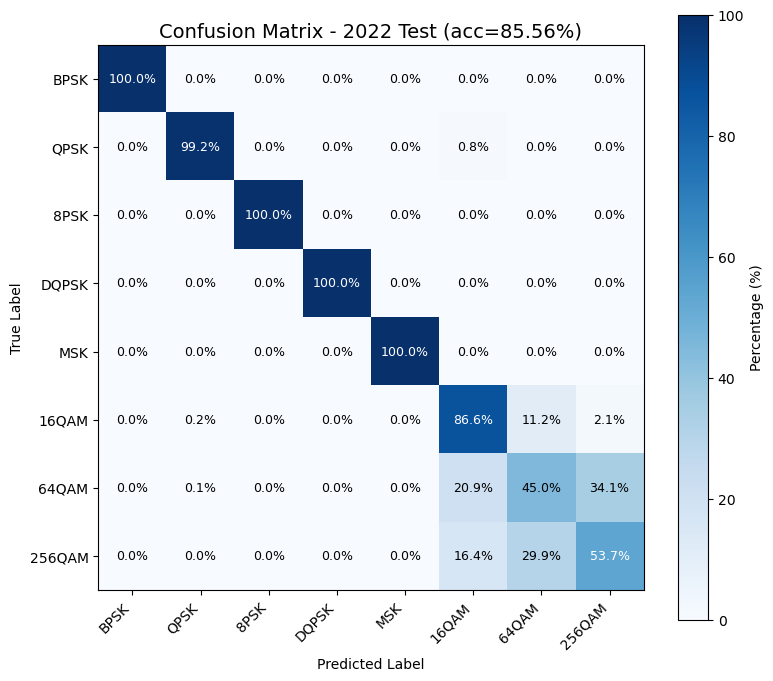

2018 TEST (external): loss=0.4213 acc=80.86%


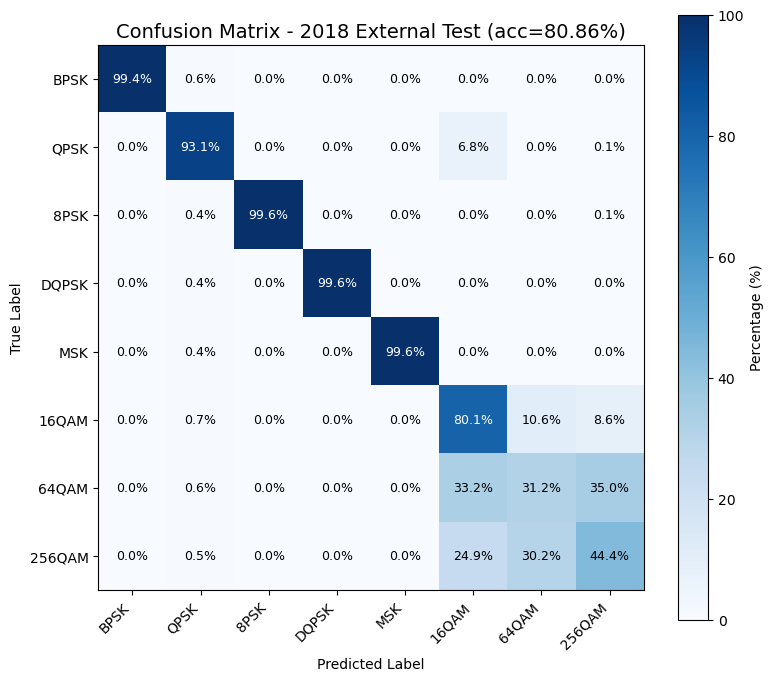

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix

# =========================
# Load final model
# =========================
ckpt = torch.load(FINAL_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
print("Loaded:", FINAL_MODEL_PATH)
print("Saved epoch:", ckpt["epoch"])

@torch.no_grad()
def plot_confusion(cm, title, class_names):
    """
    Row-normalized confusion matrix (percentage display).
    """
    cm = cm.astype(np.float64)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    cm_percent = cm / row_sums * 100.0

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(
        cm_percent,
        interpolation="nearest",
        cmap="Blues",
        vmin=0,
        vmax=100
    )

    ax.set_title(title, fontsize=14)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Percentage (%)")

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    thresh = 50.0
    for i in range(cm_percent.shape[0]):
        for j in range(cm_percent.shape[1]):
            value = cm_percent[i, j]
            ax.text(
                j, i, f"{value:.1f}%",
                ha="center",
                va="center",
                color="white" if value > thresh else "black",
                fontsize=9
            )

    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

CLASS_NAMES = ['BPSK','QPSK','8PSK','DQPSK','MSK','16QAM','64QAM','256QAM']

# =========================
# same-domain test
# =========================
te_loss, te_acc, y_true, y_pred = eval_one(model, test_loader, DEVICE, criterion)
cm = confusion_matrix(y_true, y_pred, labels=list(range(8)))
print(f"{TRAIN_SET_NAME} TEST: loss={te_loss:.4f} acc={te_acc*100:.2f}%")
plot_confusion(
    cm,
    f"Confusion Matrix - {TRAIN_SET_NAME} Test (acc={te_acc*100:.2f}%)",
    CLASS_NAMES
)

# =========================
# external test
# =========================
ex_loss, ex_acc, y_true_ex, y_pred_ex = eval_one(model, ext_test_loader, DEVICE, criterion)
cm_ex = confusion_matrix(y_true_ex, y_pred_ex, labels=list(range(8)))
print(f"{EXT_SET_NAME} TEST (external): loss={ex_loss:.4f} acc={ex_acc*100:.2f}%")
plot_confusion(
    cm_ex,
    f"Confusion Matrix - {EXT_SET_NAME} External Test (acc={ex_acc*100:.2f}%)",
    CLASS_NAMES
)

[1]J. A. Snoap, D. C. Popescu, J. A. Latshaw, and C. M. Spooner, “Deep-Learning-Based Classification of Digitally Modulated Signals Using Capsule Networks and Cyclic Cumulants,” Sensors, vol. 23, no. 12, pp. 5735–5735, Jun. 2023, doi: https://doi.org/10.3390/s23125735.
‌